In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef, roc_auc_score
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# --- 2. ربط Google Drive ---
drive.mount('/content/drive')

# --- 3. إعداد المسار ---
X = np.load('/content/drive/MyDrive/alphabet/images_over.npy')
y = np.load('/content/drive/MyDrive/alphabet/encoded_labels_over.npy')

print("✅ تم تحميل البيانات بنجاح")
print("شكل الصور:", X.shape)
print("شكل التسميات:", y.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ تم تحميل البيانات بنجاح
شكل الصور: (55520, 64, 64, 1)
شكل التسميات: (55520,)


In [ ]:
# عدد الإطارات في كل sequence
sequence_length = 10

# عدد التسلسلات الممكنة
num_sequences = len(X) // sequence_length

# اقتص الصور عشان يتقسموا تمامًا على 10
X = X[:num_sequences * sequence_length]
y = y[:num_sequences * sequence_length]

# أعد تشكيل البيانات
X_seq = X.reshape((num_sequences, sequence_length, 64, 64, 1))
y_seq = y[::sequence_length]  # نأخذ label لكل sequence

print("✅ X_seq shape:", X_seq.shape)
print("✅ y_seq shape:", y_seq.shape)

# ✨ تقسيم البيانات Train/Val/Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_seq, y_seq, test_size=0.3, random_state=42, stratify=y_seq
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("📊 Training data shape:", X_train.shape, y_train.shape)
print("📊 Validation data shape:", X_val.shape, y_val.shape)
print("📊 Test data shape:", X_test.shape, y_test.shape)


✅ X_seq shape: (5552, 10, 64, 64, 1)
✅ y_seq shape: (5552,)
📊 Training data shape: (3886, 10, 64, 64, 1) (3886,)
📊 Validation data shape: (833, 10, 64, 64, 1) (833,)
📊 Test data shape: (833, 10, 64, 64, 1) (833,)


In [ ]:
num_classes = len(np.unique(y_seq))
frames = X_seq.shape[1]

model = Sequential()

# Block 1
model.add(TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'),
                          input_shape=(frames, 64, 64, 1)))
model.add(TimeDistributed(BatchNormalization()))
model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))

# Block 2
model.add(TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')))
model.add(TimeDistributed(BatchNormalization()))
model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))

# Block 3
model.add(TimeDistributed(Conv2D(128, (3, 3), activation='relu', padding='same')))
model.add(TimeDistributed(BatchNormalization()))
model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))

# Block 4
model.add(TimeDistributed(Conv2D(256, (3, 3), activation='relu', padding='same')))
model.add(TimeDistributed(BatchNormalization()))
model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))

# Block 5
model.add(TimeDistributed(Conv2D(512, (3, 3), activation='relu', padding='same')))
model.add(TimeDistributed(BatchNormalization()))
model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))

# Flatten
model.add(TimeDistributed(Flatten()))

# LSTM
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.5))

# Output
model.add(Dense(num_classes, activation='softmax'))

# Compile
model.compile(optimizer=Adam(1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 10, 64, 64, 32) │           320 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 64, 64, 32) │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 32, 32, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 32, 32, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 32, 32, 64) │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 10, 16, 16, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 10, 16, 16,     │        73,856 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 10, 16, 16,     │           512 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 10, 8, 8, 128)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 10, 8, 8, 256)  │       295,168 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 10, 8, 8, 256)  │         1,024 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 10, 4, 4, 256)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 10, 4, 4, 512)  │     1,180,160 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_13             │ (None, 10, 4, 4, 512)  │         2,048 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_14             │ (None, 10, 2, 2, 512)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_15             │ (None, 10, 2048)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │     1,114,62

 Total params: 2,690,720 (10.26 MB)

 Trainable params: 2,688,736 (10.26 MB)

 Non-trainable params: 1,984 (7.75 KB)


================ Run 1 ================

Epoch 1/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 59s 90ms/step - accuracy: 0.1166 - loss: 3.2492 - val_accuracy: 0.4778 - val_loss: 2.1821
Epoch 2/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.3998 - loss: 2.1469 - val_accuracy: 0.7035 - val_loss: 1.3268
Epoch 3/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.6171 - loss: 1.4401 - val_accuracy: 0.8391 - val_loss: 0.8800
Epoch 4/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.7525 - loss: 0.9999 - val_accuracy: 0.9052 - val_loss: 0.6119
Epoch 5/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - accuracy: 0.8396 - loss: 0.6975 - val_accuracy: 0.9328 - val_loss: 0.4433
Epoch 6/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.9015 - loss: 0.4966 - val_accuracy: 0.9436 - val_loss: 0.3389
Epoch 7/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.9356 - loss: 0.3674 - val_accuracy: 0.9640 - val_loss: 0.2595
Epoch 8/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms

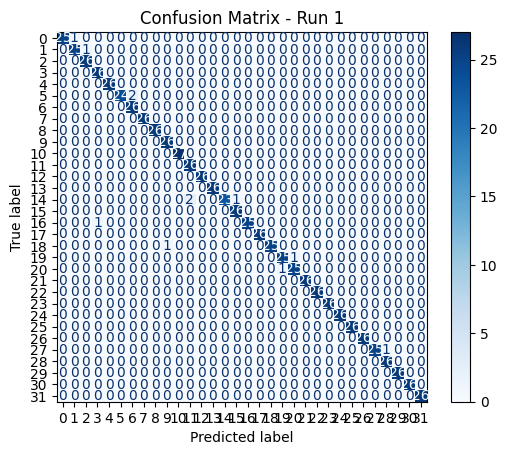

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step

================ Run 2 ================

Epoch 1/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 59s 89ms/step - accuracy: 0.1049 - loss: 3.2734 - val_accuracy: 0.4286 - val_loss: 2.2972
Epoch 2/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.3489 - loss: 2.3288 - val_accuracy: 0.6218 - val_loss: 1.5782
Epoch 3/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.5618 - loss: 1.6276 - val_accuracy: 0.7983 - val_loss: 0.9509
Epoch 4/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.7225 - loss: 1.0979 - val_accuracy: 0.8896 - val_loss: 0.6861
Epoch 5/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.8202 - loss: 0.7857 - val_accuracy: 0.9064 - val_loss: 0.5179
Epoch 6/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.8763 - loss: 0.5798 - val_accuracy: 0.9460 - val_loss: 0.3632
Epoch 7/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.9279 - loss: 0.3824 - val_accuracy: 0.9544 - val_loss: 0.2904
Epoch 8/

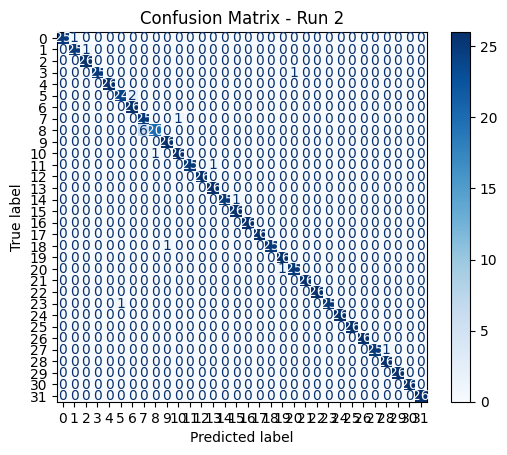

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step

================ Run 3 ================

Epoch 1/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 59s 90ms/step - accuracy: 0.1196 - loss: 3.1780 - val_accuracy: 0.5174 - val_loss: 2.0735
Epoch 2/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.4147 - loss: 2.1738 - val_accuracy: 0.7167 - val_loss: 1.3405
Epoch 3/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 81s 85ms/step - accuracy: 0.6290 - loss: 1.4210 - val_accuracy: 0.8475 - val_loss: 0.8634
Epoch 4/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 85ms/step - accuracy: 0.7527 - loss: 1.0064 - val_accuracy: 0.9016 - val_loss: 0.6073
Epoch 5/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 43s 88ms/step - accuracy: 0.8412 - loss: 0.7000 - val_accuracy: 0.9472 - val_loss: 0.4182
Epoch 6/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.9035 - loss: 0.4928 - val_accuracy: 0.9460 - val_loss: 0.3487
Epoch 7/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.9272 - loss: 0.3797 - val_accuracy: 0.9640 - val_loss: 0.2492
Epoch 8/

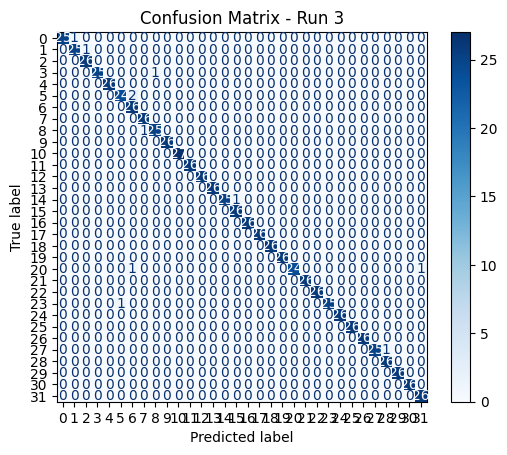

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

================ Run 4 ================

Epoch 1/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 61s 92ms/step - accuracy: 0.1168 - loss: 3.2512 - val_accuracy: 0.4430 - val_loss: 2.2655
Epoch 2/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.3685 - loss: 2.2636 - val_accuracy: 0.7275 - val_loss: 1.4368
Epoch 3/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.5826 - loss: 1.5202 - val_accuracy: 0.8247 - val_loss: 0.9279
Epoch 4/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 85ms/step - accuracy: 0.7399 - loss: 1.0511 - val_accuracy: 0.8860 - val_loss: 0.6657
Epoch 5/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 85ms/step - accuracy: 0.8574 - loss: 0.6860 - val_accuracy: 0.9328 - val_loss: 0.4569
Epoch 6/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 85ms/step - accuracy: 0.9073 - loss: 0.4971 - val_accuracy: 0.9520 - val_loss: 0.3417
Epoch 7/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 85ms/step - accuracy: 0.9313 - loss: 0.3963 - val_accuracy: 0.9604 - val_loss: 0.2755
Epoch 8/

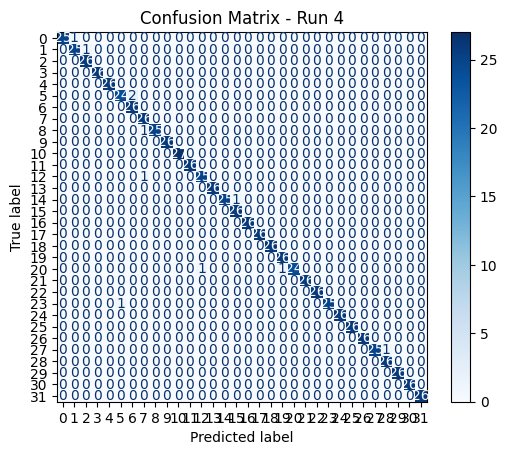

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

================ Run 5 ================

Epoch 1/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 60s 92ms/step - accuracy: 0.1015 - loss: 3.2993 - val_accuracy: 0.4886 - val_loss: 2.2888
Epoch 2/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 79s 86ms/step - accuracy: 0.3926 - loss: 2.2114 - val_accuracy: 0.6639 - val_loss: 1.5314
Epoch 3/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.5853 - loss: 1.5680 - val_accuracy: 0.8103 - val_loss: 0.9737
Epoch 4/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - accuracy: 0.7592 - loss: 1.0117 - val_accuracy: 0.8932 - val_loss: 0.6500
Epoch 5/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - accuracy: 0.8491 - loss: 0.7099 - val_accuracy: 0.9328 - val_loss: 0.4403
Epoch 6/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 41s 85ms/step - accuracy: 0.9084 - loss: 0.4937 - val_accuracy: 0.9532 - val_loss: 0.3318
Epoch 7/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.9342 - loss: 0.3694 - val_accuracy: 0.9784 - val_loss: 0.2279
Epoch 8/

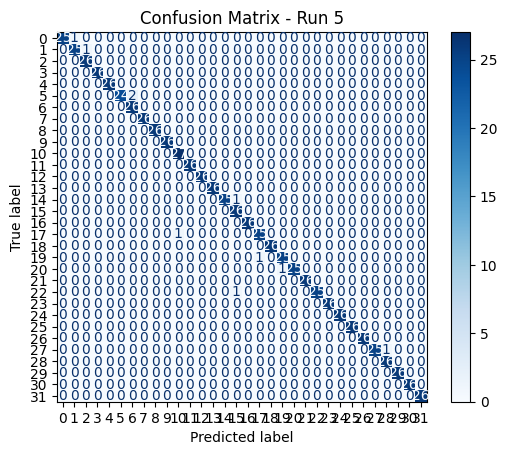

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

================ Run 6 ================

Epoch 1/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 61s 92ms/step - accuracy: 0.1026 - loss: 3.2664 - val_accuracy: 0.4130 - val_loss: 2.3847
Epoch 2/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.3649 - loss: 2.3010 - val_accuracy: 0.6591 - val_loss: 1.5342
Epoch 3/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.5814 - loss: 1.5600 - val_accuracy: 0.8139 - val_loss: 1.0151
Epoch 4/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.7282 - loss: 1.0798 - val_accuracy: 0.8752 - val_loss: 0.6546
Epoch 5/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.8203 - loss: 0.7445 - val_accuracy: 0.9028 - val_loss: 0.5026
Epoch 6/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.8705 - loss: 0.5855 - val_accuracy: 0.9484 - val_loss: 0.3672
Epoch 7/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - accuracy: 0.9275 - loss: 0.3935 - val_accuracy: 0.9556 - val_loss: 0.2838
Epoch 8/

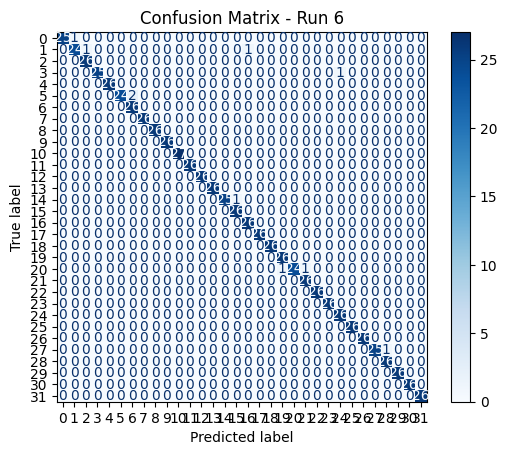

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

================ Run 7 ================

Epoch 1/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 61s 93ms/step - accuracy: 0.1183 - loss: 3.2404 - val_accuracy: 0.5006 - val_loss: 2.1424
Epoch 2/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.3891 - loss: 2.1644 - val_accuracy: 0.6807 - val_loss: 1.4174
Epoch 3/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.6080 - loss: 1.4530 - val_accuracy: 0.8031 - val_loss: 0.9564
Epoch 4/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.7370 - loss: 1.0423 - val_accuracy: 0.8872 - val_loss: 0.6428
Epoch 5/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.8300 - loss: 0.7362 - val_accuracy: 0.9160 - val_loss: 0.4732
Epoch 6/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.8850 - loss: 0.5313 - val_accuracy: 0.9376 - val_loss: 0.3608
Epoch 7/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.9245 - loss: 0.3841 - val_accuracy: 0.9652 - val_loss: 0.2569
Epoch 8/

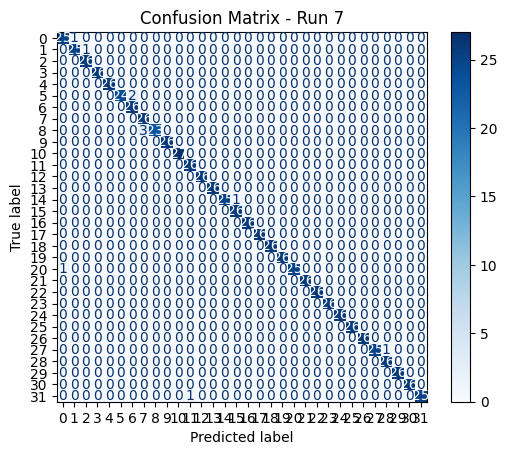

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

================ Run 8 ================

Epoch 1/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 61s 93ms/step - accuracy: 0.0995 - loss: 3.2839 - val_accuracy: 0.4166 - val_loss: 2.4294
Epoch 2/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.3436 - loss: 2.3288 - val_accuracy: 0.6831 - val_loss: 1.4855
Epoch 3/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.5866 - loss: 1.5683 - val_accuracy: 0.7995 - val_loss: 0.9813
Epoch 4/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.7433 - loss: 1.0531 - val_accuracy: 0.8992 - val_loss: 0.6528
Epoch 5/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.8322 - loss: 0.7111 - val_accuracy: 0.9244 - val_loss: 0.4580
Epoch 6/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.9018 - loss: 0.5147 - val_accuracy: 0.9592 - val_loss: 0.3268
Epoch 7/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 43s 89ms/step - accuracy: 0.9368 - loss: 0.3597 - val_accuracy: 0.9652 - val_loss: 0.2611
Epoch 8/

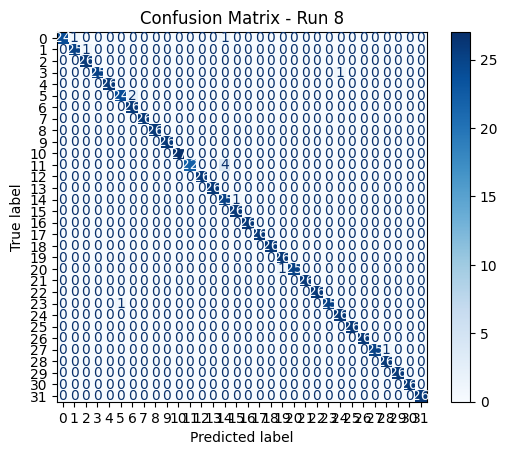

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

================ Run 9 ================

Epoch 1/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 62s 92ms/step - accuracy: 0.1156 - loss: 3.2649 - val_accuracy: 0.4958 - val_loss: 2.1800
Epoch 2/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.3979 - loss: 2.1907 - val_accuracy: 0.7107 - val_loss: 1.3549
Epoch 3/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 82s 86ms/step - accuracy: 0.6104 - loss: 1.4779 - val_accuracy: 0.8175 - val_loss: 0.9310
Epoch 4/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.7350 - loss: 1.0333 - val_accuracy: 0.8824 - val_loss: 0.6180
Epoch 5/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.8218 - loss: 0.7436 - val_accuracy: 0.9304 - val_loss: 0.4478
Epoch 6/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 43s 88ms/step - accuracy: 0.8857 - loss: 0.5326 - val_accuracy: 0.9460 - val_loss: 0.3434
Epoch 7/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.9184 - loss: 0.3976 - val_accuracy: 0.9652 - val_loss: 0.2646
Epoch 8/

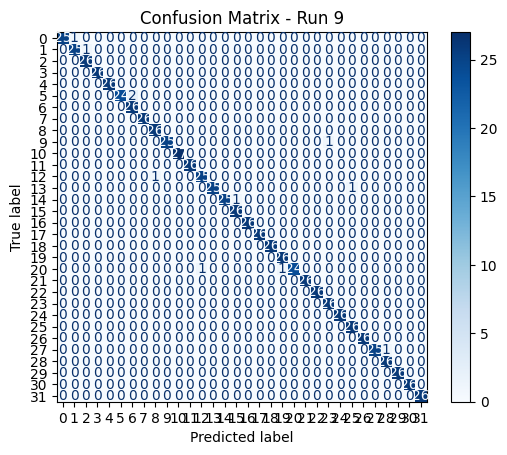

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step

================ Run 10 ================

Epoch 1/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 61s 93ms/step - accuracy: 0.1402 - loss: 3.2149 - val_accuracy: 0.4334 - val_loss: 2.1702
Epoch 2/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 43s 89ms/step - accuracy: 0.4142 - loss: 2.1107 - val_accuracy: 0.7059 - val_loss: 1.3399
Epoch 3/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.6191 - loss: 1.4085 - val_accuracy: 0.8235 - val_loss: 0.8336
Epoch 4/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.7439 - loss: 0.9738 - val_accuracy: 0.8824 - val_loss: 0.6039
Epoch 5/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.8341 - loss: 0.7119 - val_accuracy: 0.9208 - val_loss: 0.4467
Epoch 6/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 43s 88ms/step - accuracy: 0.8859 - loss: 0.5166 - val_accuracy: 0.9460 - val_loss: 0.3409
Epoch 7/20
486/486 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.9267 - loss: 0.3641 - val_accuracy: 0.9580 - val_loss: 0.2823
Epoch 8

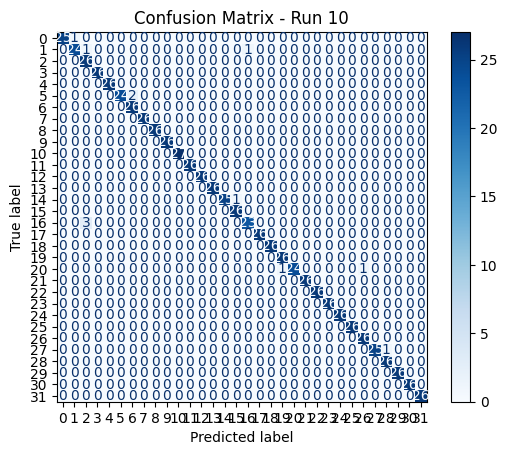

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
   Run  Val_Accuracy  Val_Loss       MCC   ROC_AUC  F1_Weighted  \
0    1      0.985594  0.086132  0.985151  0.998971     0.985534   
1    2      0.977191  0.114269  0.976504  0.998369     0.977107   
2    3      0.986795  0.086617  0.986386  0.998241     0.986807   
3    4      0.986795  0.075819  0.986385  0.998631     0.986787   
4    5      0.987995  0.092017  0.987623  0.998631     0.988011   
5    6      0.987995  0.084713  0.987626  0.998341     0.987941   
6    7      0.986795  0.092436  0.986394  0.997607     0.986777   
7    8      0.983193  0.088627  0.982688  0.998520     0.983221   
8    9      0.986795  0.090246  0.986386  0.998001     0.986764   
9   10      0.985594  0.098790  0.985159  0.998161     0.985593   

   Precision_Weighted  Recall_Weighted  Training_Time(s)  Memory_Used(MB)  
0            0.986160         0.985594        835.727035       339.402344  
1            0.978457         0.977191        836.597090       241.265

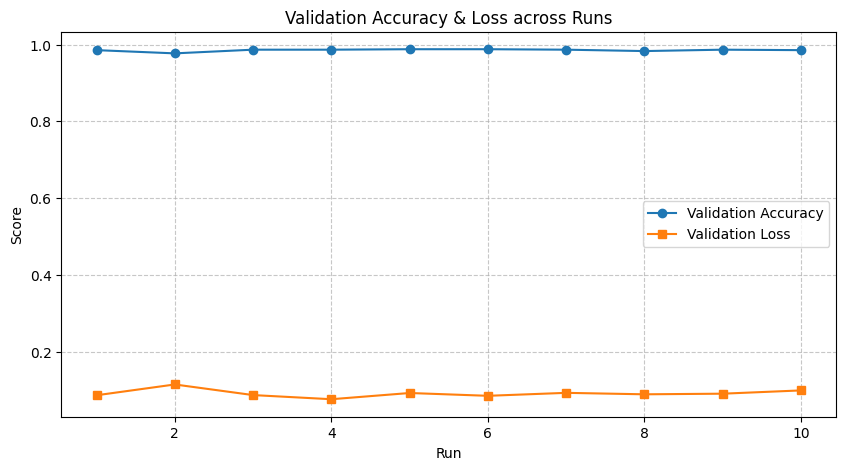

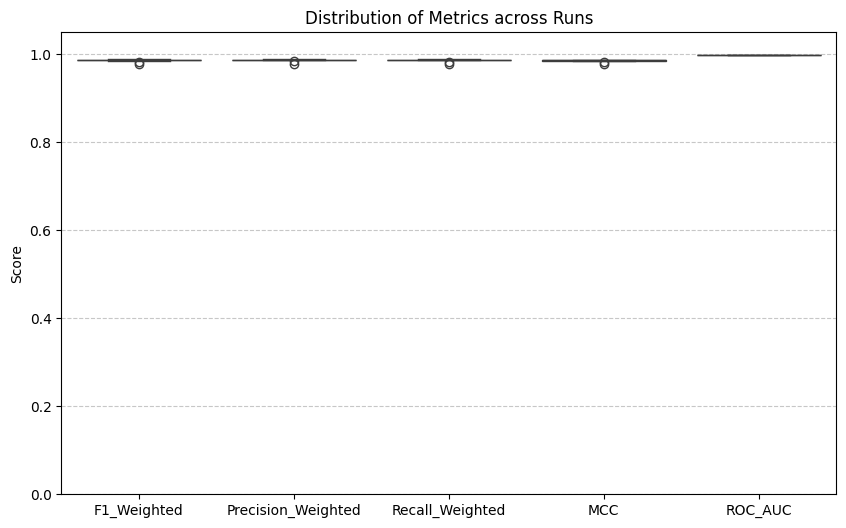

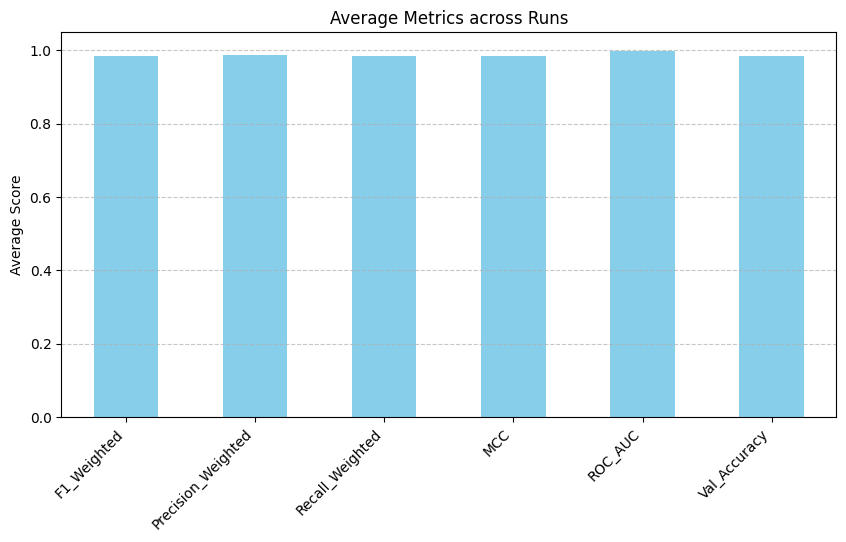

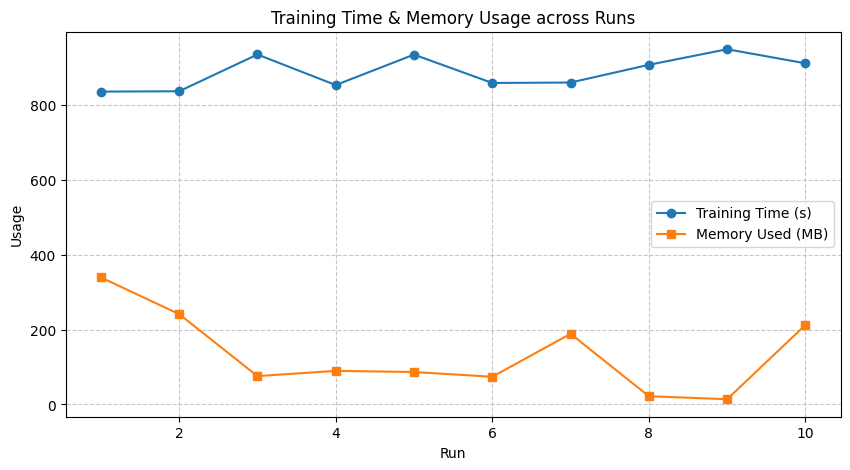

In [ ]:
import time
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

results = []
num_runs = 10  # عدد مرات التشغيل

for run in range(1, num_runs+1):
    print(f"\n================ Run {run} ================\n")

    # --- قياس الوقت والذاكرة قبل التدريب ---
    start_time = time.time()
    start_mem = psutil.Process().memory_info().rss / (1024 ** 2)  # MB

    # إعادة بناء الموديل كل Run
    model_run = tf.keras.models.clone_model(model)
    model_run.compile(optimizer=Adam(1e-4),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

    # تدريب النموذج
    history = model_run.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=8,
        verbose=1
    )

    # --- قياس الوقت والذاكرة بعد التدريب ---
    end_time = time.time()
    end_mem = psutil.Process().memory_info().rss / (1024 ** 2)
    train_time = end_time - start_time
    train_memory = end_mem - start_mem

    # تقييم
    val_loss, val_acc = model_run.evaluate(X_val, y_val, verbose=0)

    # --- Confusion Matrix ---
    y_pred = np.argmax(model_run.predict(X_val), axis=1)
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - Run {run}")
    plt.show()

    # --- MCC ---
    mcc = matthews_corrcoef(y_val, y_pred)

    # --- ROC AUC ---
    y_val_bin = label_binarize(y_val, classes=np.arange(num_classes))
    y_pred_prob = model_run.predict(X_val)
    roc_auc = roc_auc_score(y_val_bin, y_pred_prob, average='macro', multi_class='ovr')

    # --- Weighted Metrics ---
    f1_w = f1_score(y_val, y_pred, average='weighted')
    precision_w = precision_score(y_val, y_pred, average='weighted')
    recall_w = recall_score(y_val, y_pred, average='weighted')

    # حفظ النتائج
    results.append({
        'Run': run,
        'Val_Accuracy': val_acc,
        'Val_Loss': val_loss,
        'MCC': mcc,
        'ROC_AUC': roc_auc,
        'F1_Weighted': f1_w,
        'Precision_Weighted': precision_w,
        'Recall_Weighted': recall_w,
        'Training_Time(s)': train_time,
        'Memory_Used(MB)': train_memory
    })

# --- تحويل النتائج ل DataFrame ---
df_results = pd.DataFrame(results)
print(df_results)

# --- حفظ النتائج ---
df_results.to_excel("metrics_with_f1_precision_recall_time_memory.xlsx", index=False)
print("\n✅ Saved to metrics_with_f1_precision_recall_time_memory.xlsx")

# =================== 📊 الرسومات ===================

# 1. Accuracy & Loss عبر الـ Runs
plt.figure(figsize=(10,5))
plt.plot(df_results['Run'], df_results['Val_Accuracy'], marker='o', label='Validation Accuracy')
plt.plot(df_results['Run'], df_results['Val_Loss'], marker='s', label='Validation Loss')
plt.xlabel("Run")
plt.ylabel("Score")
plt.title("Validation Accuracy & Loss across Runs")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

# 2. Boxplot للـ Metrics
metrics_cols = ['F1_Weighted', 'Precision_Weighted', 'Recall_Weighted', 'MCC', 'ROC_AUC']
plt.figure(figsize=(10,6))
sns.boxplot(data=df_results[metrics_cols])
plt.title("Distribution of Metrics across Runs")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.show()

# 3. Bar chart للمتوسطات
avg_results = df_results.mean(numeric_only=True)
plt.figure(figsize=(10,5))
avg_results[metrics_cols + ['Val_Accuracy']].plot(kind='bar', color='skyblue')
plt.title("Average Metrics across Runs")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.show()

# 4. Training Time & Memory Usage
plt.figure(figsize=(10,5))
plt.plot(df_results['Run'], df_results['Training_Time(s)'], marker='o', label='Training Time (s)')
plt.plot(df_results['Run'], df_results['Memory_Used(MB)'], marker='s', label='Memory Used (MB)')
plt.xlabel("Run")
plt.ylabel("Usage")
plt.title("Training Time & Memory Usage across Runs")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()


In [ ]:
df_results = pd.DataFrame(results)
df_results.to_excel('/content/drive/MyDrive/alphabet/CNN_Lstm_analysis_Over.xlsx', index=False)
print("✅ Results saved to CNN_runs_analysis.xlsx")
print(df_results)


✅ Results saved to CNN_runs_analysis.xlsx
   Run  Val_Accuracy  Val_Loss       MCC   ROC_AUC  F1_Weighted  \
0    1      0.985594  0.086132  0.985151  0.998971     0.985534   
1    2      0.977191  0.114269  0.976504  0.998369     0.977107   
2    3      0.986795  0.086617  0.986386  0.998241     0.986807   
3    4      0.986795  0.075819  0.986385  0.998631     0.986787   
4    5      0.987995  0.092017  0.987623  0.998631     0.988011   
5    6      0.987995  0.084713  0.987626  0.998341     0.987941   
6    7      0.986795  0.092436  0.986394  0.997607     0.986777   
7    8      0.983193  0.088627  0.982688  0.998520     0.983221   
8    9      0.986795  0.090246  0.986386  0.998001     0.986764   
9   10      0.985594  0.098790  0.985159  0.998161     0.985593   

   Precision_Weighted  Recall_Weighted  Training_Time(s)  Memory_Used(MB)  
0            0.986160         0.985594        835.727035       339.402344  
1            0.978457         0.977191        836.597090       241.2


📊 Average Results across all runs:
Average Accuracy        : 0.9855
Average Loss            : 0.0910
Average MCC             : 0.9850
Average ROC AUC         : 0.9983
Average F1_Weighted     : 0.9855
Average Precision_W     : 0.9862
Average Recall_W        : 0.9855
Average Training Time(s): 888.10
Average Memory Used(MB) : 134.40

✅ Results saved to /content/drive/MyDrive/CNN_Lstm_results_over_average.xlsx


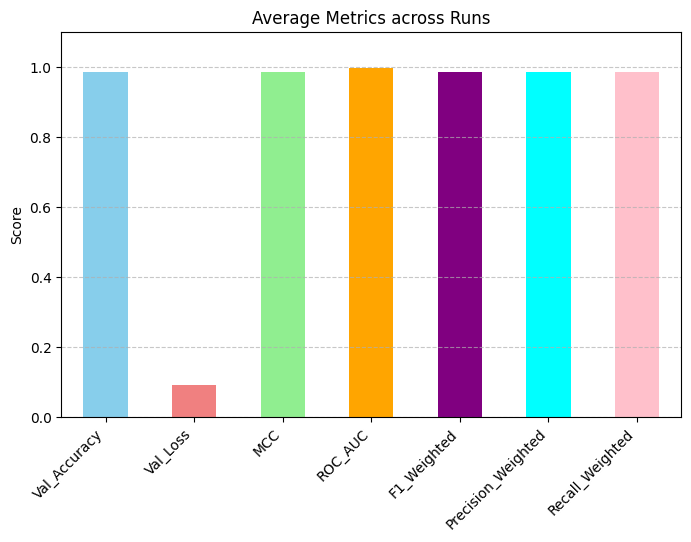

In [ ]:
import matplotlib.pyplot as plt

# --- تحويل النتائج ل DataFrame ---
results_df = pd.DataFrame(results)

# --- حساب المتوسط لكل مقياس ---
avg_results = results_df.mean(numeric_only=True)

print("\n📊 Average Results across all runs:")
print(f"Average Accuracy        : {avg_results['Val_Accuracy']:.4f}")
print(f"Average Loss            : {avg_results['Val_Loss']:.4f}")
print(f"Average MCC             : {avg_results['MCC']:.4f}")
print(f"Average ROC AUC         : {avg_results['ROC_AUC']:.4f}")
print(f"Average F1_Weighted     : {avg_results['F1_Weighted']:.4f}")
print(f"Average Precision_W     : {avg_results['Precision_Weighted']:.4f}")
print(f"Average Recall_W        : {avg_results['Recall_Weighted']:.4f}")
print(f"Average Training Time(s): {avg_results['Training_Time(s)']:.2f}")
print(f"Average Memory Used(MB) : {avg_results['Memory_Used(MB)']:.2f}")

# --- حفظ النتائج في Excel ---
save_path = "/content/drive/MyDrive/CNN_Lstm_results_over_average.xlsx"
with pd.ExcelWriter(save_path) as writer:
    results_df.to_excel(writer, sheet_name="All Runs", index=False)
    avg_results.to_frame(name="Average").to_excel(writer, sheet_name="Average")

print(f"\n✅ Results saved to {save_path}")

# --- رسم المتوسطات (المقاييس من 0 لـ 1 فقط) ---
plt.figure(figsize=(8,5))
avg_results[['Val_Accuracy','Val_Loss','MCC','ROC_AUC','F1_Weighted','Precision_Weighted','Recall_Weighted']].plot(
    kind='bar',
    color=['skyblue','lightcoral','lightgreen','orange','purple','cyan','pink']
)
plt.title("Average Metrics across Runs")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)  # معظم المقاييس بتبقى بين 0 و 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
print("Model input shape:", model.input_shape)


Model input shape: (None, 10, 64, 64, 1)


📐 Sequential Input Shape: T=10 × 64x64x1


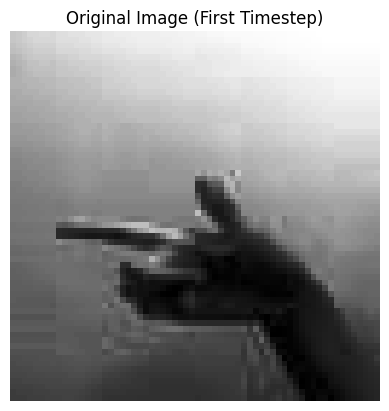

Predicted class: yaa (1.00)


  0%|          | 0/1000 [00:00<?, ?it/s]

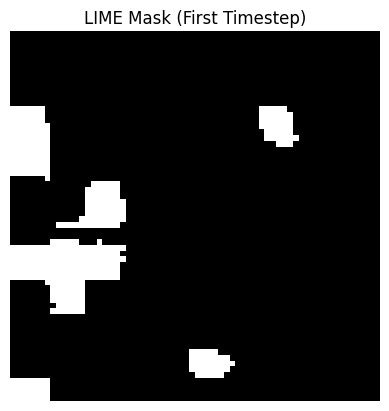

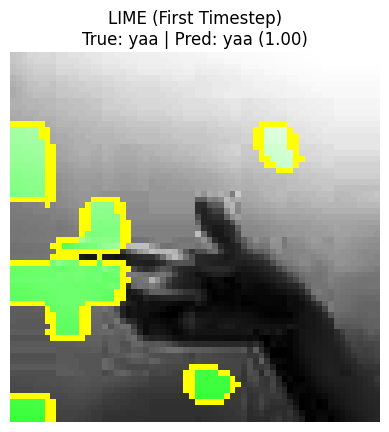

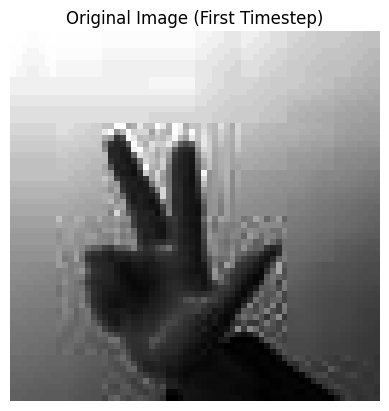

Predicted class: al (1.00)


  0%|          | 0/1000 [00:00<?, ?it/s]

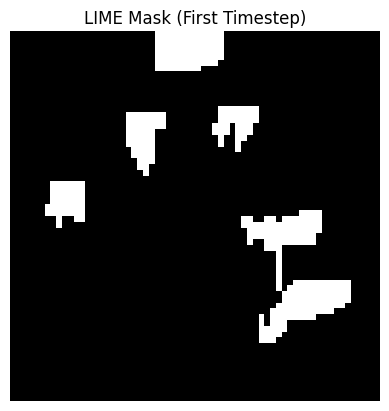

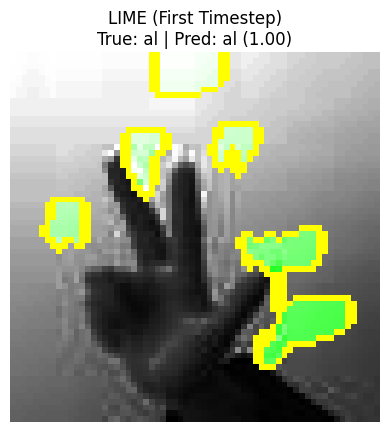

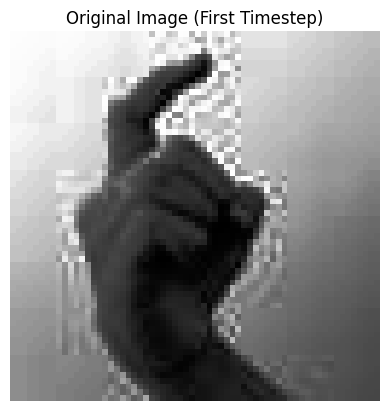

Predicted class: ra (1.00)


  0%|          | 0/1000 [00:00<?, ?it/s]

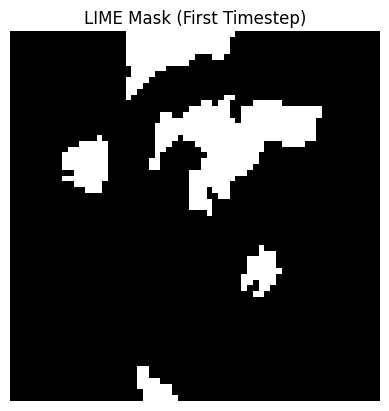

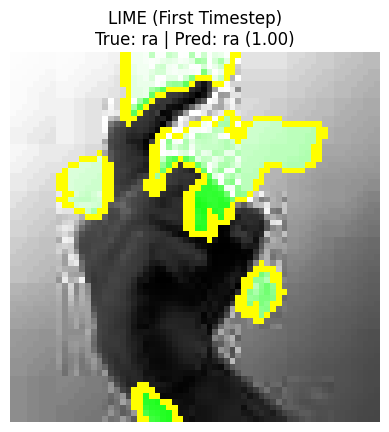

In [ ]:
!pip install lime
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from skimage.transform import resize
from skimage.color import rgb2gray  # Add for grayscale conversion

# تحميل أسماء الكلاسات
class_names = np.load('/content/drive/MyDrive/alphabet/label_encoder_classes.npy', allow_pickle=True)

# استخراج شكل مدخلات الموديل
full_input_shape = model.input_shape  # e.g., (None, 10, 64, 64, 1)
input_shape = full_input_shape[1:]    # Remove batch dim: e.g., (10, 64, 64, 1)

T = 1
if len(input_shape) == 4 and input_shape[0] == 10 and input_shape[-1] == 1:
    T, H, W, C = input_shape  # T=10 timesteps, H/W=64, C=1 (grayscale)
    print(f"📐 Sequential Input Shape: T={T} × {H}x{W}x{C}")
elif len(input_shape) == 1:
    # 1D input (flattened): infer H, W, C assuming square grayscale (C=1) or adjust as needed
    features = input_shape[0]
    H = int(np.sqrt(features))  # Assume square; adjust if rectangular
    W = H
    C = 1  # Grayscale; set to 3 if flattened RGB
    print(f"📐 Inferred Input Shape (flattened): T={T} × {H}x{W}x{C} (total features: {features})")
elif len(input_shape) == 3:
    H, W, C = input_shape
    print(f"📐 Input Shape: T={T} × {H}x{W}x{C}")
else:
    raise ValueError(f"Unsupported input shape: {input_shape}")

# دالة تجهيز الصور زي التدريب (updated for sequential input)
def preprocess_batch(images):
    # images: list of data items, each potentially (T, H, W, C) or raw
    out = []
    for item in images:
        item = np.asarray(item)
        if item.ndim == 4 and item.shape == input_shape:  # Already (T, H, W, 1)
            im = item
        elif item.ndim == 2:  # Grayscale 2D: expand to (T, H, W, 1)
            im = np.expand_dims(item, axis=(0, -1))  # (1, H, W, 1)
            if T > 1:
                im = np.repeat(im, T, axis=0)  # Duplicate across timesteps if input is static
        elif item.ndim == 3 and item.shape[-1] == 1:  # (H, W, 1): expand to (T, H, W, 1)
            im = np.expand_dims(item, axis=0)  # (1, H, W, 1)
            if T > 1:
                im = np.repeat(im, T, axis=0)
        elif item.ndim == 3 and item.shape[-1] == 3:  # RGB image: convert to grayscale first
            gray = rgb2gray(item)  # Convert to (H, W)
            im = np.expand_dims(gray, axis=(0, -1))  # (1, H, W, 1)
            if T > 1:
                im = np.repeat(im, T, axis=0)  # Duplicate across timesteps
        else:
            # Fallback: assume it's the full sequence or handle differently
            if item.ndim == 5 and item.shape[1:] == input_shape:
                im = item[0]  # Take first batch if accidentally batched
            else:
                raise ValueError(f"Unexpected item shape: {item.shape}")

        # Resize each timestep if needed (preserves T)
        resized = np.zeros(input_shape, dtype='float32')
        for t in range(T):
            frame = im[t, :, :, 0] if C == 1 else im[t]
            frame_resized = resize(frame, (H, W), preserve_range=True, anti_aliasing=True).astype('float32')
            resized[t, :, :, 0] = frame_resized
        im = resized

        if im.max() > 1.0:
            im = im / 255.0
        out.append(im)
    return np.asarray(out, dtype='float32')

# دالة التنبؤ لـ LIME
def predict_fn(images):
    Xb = preprocess_batch(images)
    return model.predict(Xb, verbose=0)

# إنشاء مفسر LIME
explainer = lime_image.LimeImageExplainer()

# اختيار صور عشوائية للتفسير
indices = np.random.choice(len(X_val), size=3, replace=False)

for idx in indices:
    data_item = X_val[idx]  # Assume (T, H, W, C)

    # تجهيز نسخة RGB للعرض (use first timestep as representative)
    if data_item.ndim == 4:
        frame = data_item[0]  # First timestep
    else:
        frame = data_item
    if frame.ndim == 2 or frame.shape[-1] == 1:
        image_rgb = np.repeat(frame[..., np.newaxis], 3, axis=-1)
        image_rgb = np.squeeze(image_rgb)
    else:
        image_rgb = frame[..., :3]

    # --- عرض الصورة الأصلية (first frame) ---
    plt.figure()
    plt.imshow(image_rgb, cmap='gray' if C == 1 else None)
    plt.title("Original Image (First Timestep)")
    plt.axis('off')
    plt.show()

    # --- تنبؤ الموديل ---
    pred_probs = model.predict(preprocess_batch([data_item]), verbose=0)[0]
    pred_label = int(np.argmax(pred_probs))
    print(f"Predicted class: {class_names[pred_label]} ({pred_probs[pred_label]:.2f})")

    # --- تفسير LIME (on first frame as static image) ---
    explanation = explainer.explain_instance(
        image_rgb.astype('double'),  # Use double for precision
        predict_fn,
        labels=[pred_label],
        hide_color=0,
        num_samples=1000,
        segmentation_fn=slic
    )

    # --- استخراج الـ mask ---
    temp, mask = explanation.get_image_and_mask(
        pred_label,
        positive_only=False,
        num_features=10,
        hide_rest=False
    )

    # --- عرض الـ mask ---
    plt.figure()
    plt.imshow(mask, cmap='gray')
    plt.title("LIME Mask (First Timestep)")
    plt.axis('off')
    plt.show()

    # --- عرض الصورة مع الحدود ---
    true_class_name = class_names[int(y_val[idx])]
    predicted_class_name = class_names[pred_label]
    plt.figure()
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f"LIME (First Timestep)\nTrue: {true_class_name} | Pred: {predicted_class_name} ({pred_probs[pred_label]:.2f})")
    plt.axis('off')
    plt.show()

In [ ]:
import numpy as np

# حفظ الموديل بصيغة Keras الجديدة
model.save('/content/drive/MyDrive/alphabet/my_modelcnn_lstm_over.keras')

# حفظ بيانات validation (لو محتاجة تكمل عليها)
np.save('/content/drive/MyDrive/alphabet/x_val_cnn_Lstm_over.npy', X_val)
np.save('/content/drive/MyDrive/alphabet/y_val_cnn_lstm_over.npy', y_val)
